In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/job_salary_prediction_dataset.csv")

X = df.drop("salary", axis=1)
y = df["salary"]

df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [1]:
categorical_features = [
    "job_title",
    "education_level",
    "industry",
    "company_size",
    "location",
    "remote_work"
]

numeric_features = [
    "experience_years",
    "skills_count",
    "certifications"
]

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [10]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [36]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['job_title','experience_years','education_level',...,'location', 'remote_work','certifications']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [37]:
y_pred = lr_pipeline.predict(X_test)

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np 

In [38]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(
    y_test,
    y_pred,
)
rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
# how much variance is covered by linear regression
print("R2:", r2)

MAE: 5427.152810732096
RMSE: 7088.93628973907
R2: 0.9624322031180702


In [21]:
df.sample(10)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
49766,Machine Learning Engineer,0,High School,9,Consulting,Enterprise,Netherlands,Yes,4,137069
169871,Product Manager,14,High School,17,Finance,Large,USA,Yes,2,217280
106205,Data Scientist,19,PhD,15,Technology,Large,India,Hybrid,4,136799
167802,Business Analyst,4,Bachelor,19,Healthcare,Enterprise,Germany,Yes,1,149728
89739,Machine Learning Engineer,1,Diploma,19,Telecom,Medium,Australia,Hybrid,0,113456
71901,Cloud Engineer,14,Master,13,Education,Medium,Sweden,Yes,0,151309
79876,Cybersecurity Analyst,19,High School,15,Technology,Startup,Canada,Yes,1,162984
222127,AI Engineer,5,High School,18,Media,Small,Remote,Yes,2,141225
170359,Product Manager,3,Bachelor,15,Education,Startup,UK,Hybrid,5,135812
130243,Software Engineer,4,PhD,16,Government,Large,Sweden,No,0,150697


In [ ]:
df_sample = df.sample(
    n=25000,
    random_state=42
)

In [26]:
# took too long for random forest regressor
X = df_sample.drop("salary", axis=1)
y = df_sample["salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:

# RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        # 200 trees
        n_estimators=50,
        random_state=42,
        # all CPU cores
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

In [32]:
mae = mean_absolute_error(y_test, rf_pred)

mse = mean_squared_error(
    y_test,
    rf_pred,
)
rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    rf_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
# how much variance is covered by linear regression
print("R2:", r2)

MAE: 6845.996754133334
RMSE: 8767.188178350327
R2: 0.9425388600834691


In [33]:
# GRADIENT BOOSTING
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

gb_pred = gb_pipeline.predict(X_test)

In [35]:
mae = mean_absolute_error(y_test, gb_pred)

mse = mean_squared_error(
    y_test,
    gb_pred,
)
rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    gb_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
# how much variance is covered by linear regression
print("R2:", r2)

MAE: 6518.165653128566
RMSE: 8255.204955265328
R2: 0.949054092713426


In [39]:
df["salary"].describe()

count    250000.000000
mean     145718.080524
std       37407.952729
min       31867.000000
25%      119358.000000
50%      143453.000000
75%      169492.000000
max      333046.000000
Name: salary, dtype: float64

In [ ]:
# checking suspicion for why linear is performing the best
df[[
    "experience_years",
    "skills_count",
    "certifications",
    "salary"
]].corr()

,experience_years,skills_count,certifications,salary
experience_years,1.000000,0.000149,-0.000198,0.437627
skills_count,0.000149,1.000000,-0.002230,0.127300
certifications,-0.000198,-0.002230,1.000000,0.073819
salary,0.437627,0.127300,0.073819,1.000000


In [41]:
# linear regression model is best here
df["salary"].nunique()

118956

In [42]:
import joblib

joblib.dump(
    lr_pipeline,
    "../models/salary_prediction_pipeline.pkl"
)

['../models/salary_prediction_pipeline.pkl']

In [ ]:
# feature engineering
feature_names = (
    lr_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [44]:
coefficients = (
    lr_pipeline
    .named_steps["model"]
    .coef_
)

In [45]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

In [ ]:
# larger impace
importance_df.sort_values(
    "coefficient",
    ascending=False
).head(20)

,feature,coefficient
41,cat__location_USA,35673.130433
0,cat__job_title_AI Engineer,28410.163963
27,cat__company_size_Enterprise,23976.571381
33,cat__location_Canada,21693.693246
16,cat__education_level_PhD,18243.887079
9,cat__job_title_Machine Learning Engineer,17192.105016
40,cat__location_UK,14983.507635
10,cat__job_title_Product Manager,12048.600686
28,cat__company_size_Large,9975.240798
34,cat__location_Germany,7708.490766


In [48]:
importance_df.sort_values(
    "coefficient"
).head(20)

,feature,coefficient
35,cat__location_India,-48081.021417
5,cat__job_title_Data Analyst,-25821.385835
2,cat__job_title_Business Analyst,-23489.202274
31,cat__company_size_Startup,-18224.726164
14,cat__education_level_High School,-13824.528661
8,cat__job_title_Frontend Developer,-12708.235221
30,cat__company_size_Small,-11366.374640
13,cat__education_level_Diploma,-8531.430132
1,cat__job_title_Backend Developer,-6597.937823
36,cat__location_Netherlands,-6472.457847


In [49]:
from sklearn.inspection import permutation_importance

In [50]:
perm_importance = permutation_importance(
    lr_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

In [51]:
perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm_importance.importances_mean
})

perm_df.sort_values(
    "importance",
    ascending=False
)

,feature,importance
6,location,0.682182
1,experience_years,0.394739
5,company_size,0.340630
0,job_title,0.335714
2,education_level,0.199782
3,skills_count,0.032039
8,certifications,0.011076
7,remote_work,0.009588
4,industry,-0.000011


In [ ]:
# for SHAP
X_train_transformed = (
    lr_pipeline
    .named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    lr_pipeline
    .named_steps["preprocessor"]
    .transform(X_test)
)

In [53]:
model = (
    lr_pipeline
    .named_steps["model"]
)

In [ ]:
import shap # attribute prediction to individual features

# linear explainer for linear regression
explainer = shap.LinearExplainer(
    model,
    X_train_transformed
)

C:\Users\swyam\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 20000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=20000 when initializing the masker.


In [55]:
shap_values = explainer(
    X_test_transformed[:1000]
)

In [74]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test_transformed[:1000],
    feature_names=feature_names,
    show=False
)

plt.savefig(
    "../experiments/shap_outputs/summary_plot.png"
)

plt.close()

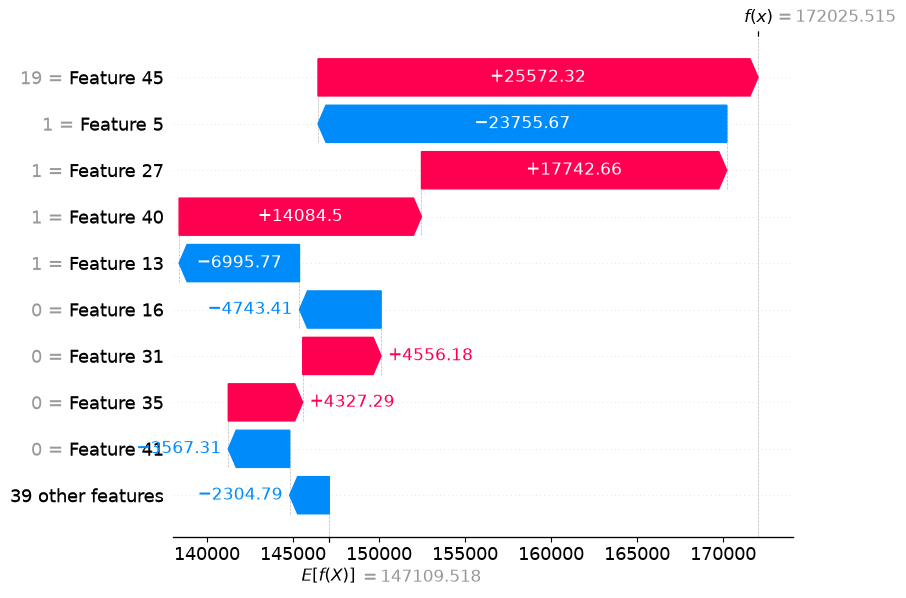

In [ ]:
sample_idx = 0


shap.plots.waterfall(
    shap_values[sample_idx]
)

In [66]:
importance_df.to_csv(
    "../experiments/feature_importance.csv",
    index=False
)

In [75]:
shap_values[0].base_values

np.float64(147109.51754847512)

In [76]:
shap_values[0].values.sum()

np.float64(24915.99733862195)

In [77]:
prediction = model.predict(
    X_test_transformed[:1]
)

print(prediction)

[172025.5148871]
